In [1]:
# https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings

In [4]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
data.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
data.shape

(144, 1)

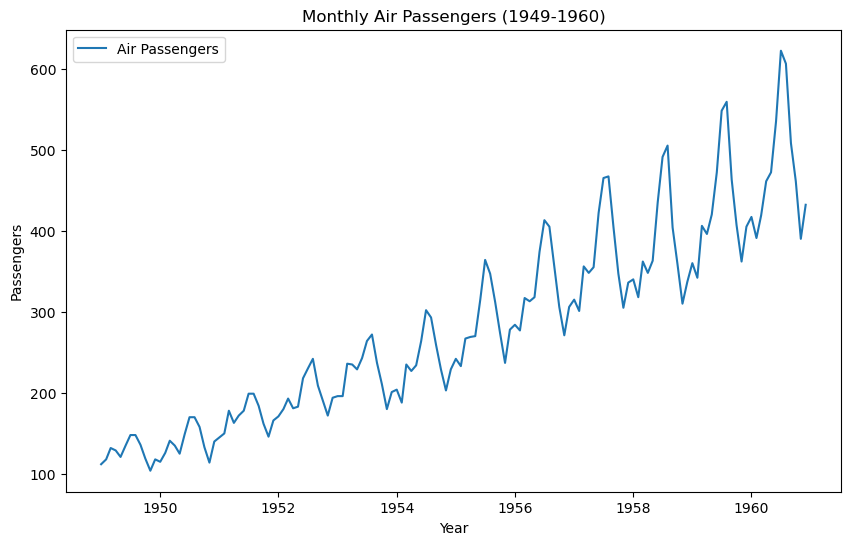

In [6]:
# Step 2: Visualize the data
plt.figure(figsize=(10, 6))
plt.plot(data, label='Air Passengers')
plt.title('Monthly Air Passengers (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.savefig('air_passengers_plot.png')
plt.show()

In [7]:
# Step 3: Check stationarity with ADF test
def check_stationarity(timeseries):
    result = adfuller(timeseries['Passengers'])
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("Data is stationary (reject null hypothesis)")
    else:
        print("Data is non-stationary (fail to reject null hypothesis)")

print("Stationarity Test (Original Data):")
check_stationarity(data)

Stationarity Test (Original Data):
ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
Data is non-stationary (fail to reject null hypothesis)


In [8]:
# Difference the data (d=1) and check again
data_diff = data.diff().dropna()
print("\nStationarity Test (After Differencing):")
check_stationarity(data_diff)


Stationarity Test (After Differencing):
ADF Statistic: -2.8292668241700047
p-value: 0.05421329028382478
Data is non-stationary (fail to reject null hypothesis)


In [9]:
# Step 4: Fit ARIMA model (p=2, d=1, q=2)
model = ARIMA(data, order=(2, 1, 2))
model_fit = model.fit()

# Print model summary
print("\nARIMA Model Summary:")
print(model_fit.summary())


ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Sat, 13 Dec 2025   AIC                           1353.347
Time:                        15:02:41   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.060      0.000       1.645       1.725
ar.L2         -0.9548      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.1


ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Sat, 13 Dec 2025   AIC                           1353.347
Time:                        15:03:23   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.060      0.000       1.645       1.725
ar.L2         -0.9548      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.1

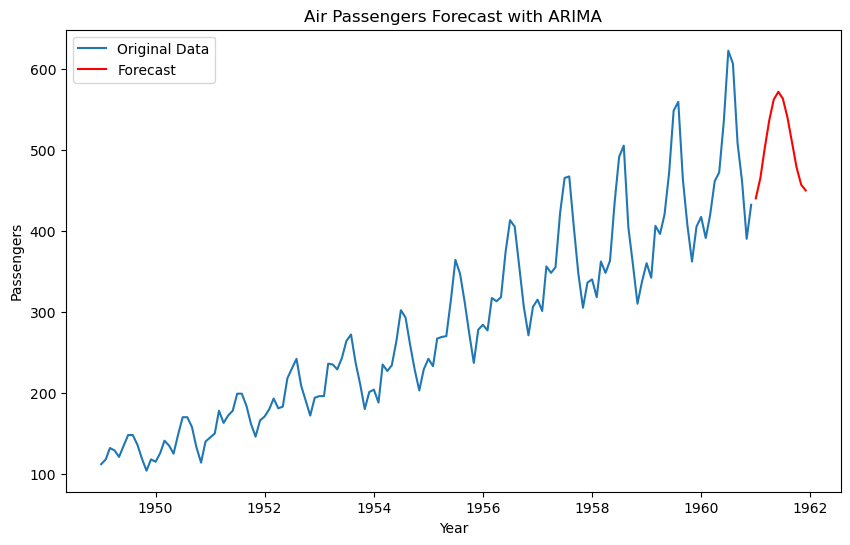

In [10]:
# Print model summary
print("\nARIMA Model Summary:")
print(model_fit.summary())

# Step 5: Forecast the next 12 months
forecast = model_fit.forecast(steps=12)

# Create date range for forecast
forecast_index = pd.date_range(start=data.index[-1], periods=13, freq='MS')[1:]  # Start after last data point

# Step 6: Plot original data and forecast
plt.figure(figsize=(10, 6))
plt.plot(data, label='Original Data')
plt.plot(forecast_index, forecast, label='Forecast', color='red')
plt.title('Air Passengers Forecast with ARIMA')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.savefig('air_passengers_forecast.png')
plt.show()